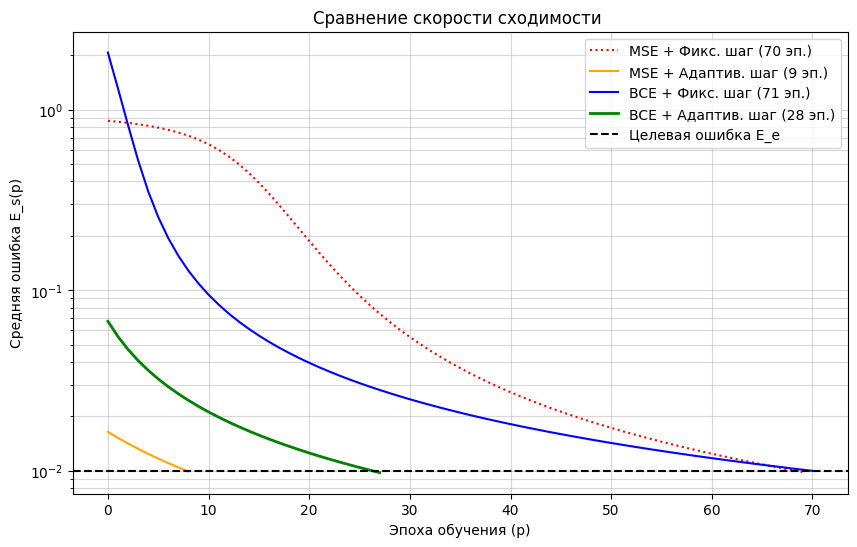

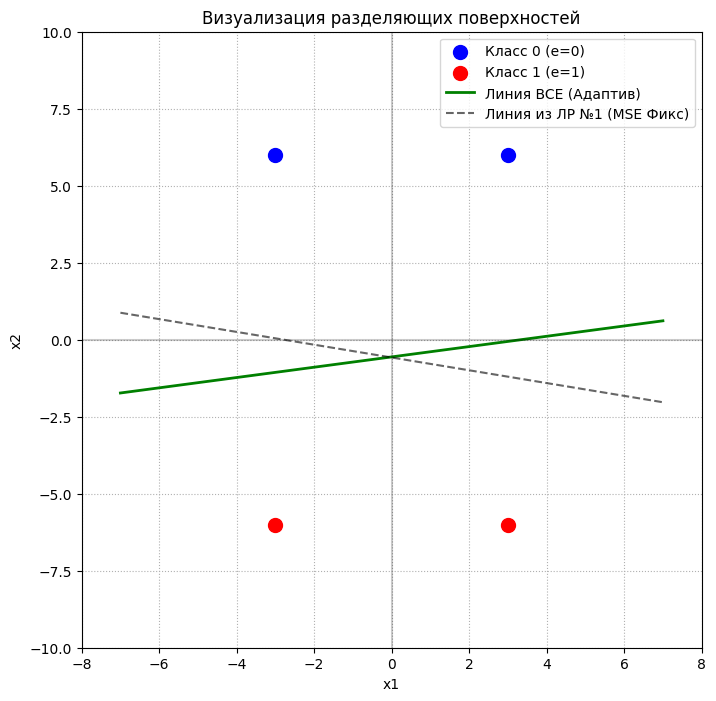


=== РЕЖИМ ТЕСТИРОВАНИЯ (BCE Адаптивный шаг) ===
Введите x1, x2 через запятую (или 'q' для выхода): 3, 5
Результат: Вероятность P=0.0169 -> Класс 0
Введите x1, x2 через запятую (или 'q' для выхода): -2, -7
Результат: Вероятность P=0.9927 -> Класс 1
Введите x1, x2 через запятую (или 'q' для выхода): 0,0
Результат: Вероятность P=0.3898 -> Класс 0
Введите x1, x2 через запятую (или 'q' для выхода): q


In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[3, 6], [-3, 6], [3, -6], [-3, -6]])
e = np.array([0, 0, 1, 1])

target_error = 0.01
max_epochs = 1000
alpha_fixed = 0.01
np.random.seed(42)


def sigmoid(S):
    return 1 / (1 + np.exp(-S))


def train_model(loss_type='BCE', step_type='fixed'):

    w = np.random.uniform(-0.5, 0.5, 2)
    T = np.random.uniform(-0.5, 0.5)
    error_history = []

    for epoch in range(max_epochs):
        epoch_errors = []
        for i in range(len(X)):
            S = np.dot(X[i], w) - T
            y = sigmoid(S)

            # Расчет ошибки для графика E_s(p)
            if loss_type == 'BCE':
                err = -(e[i] * np.log(y + 1e-15) + (1 - e[i]) * np.log(1 - y + 1e-15))
            else:
                err = (e[i] - y) ** 2
            epoch_errors.append(err)

            alpha = 1 / (1 + np.sum(X[i] ** 2)) if step_type == 'adaptive' else alpha_fixed

            # ОБНОВЛЕНИЕ ВЕСОВ
            if loss_type == 'BCE':
                # Для BCE производная сигмоиды сокращается
                w[0] = w[0] - alpha * X[i, 0] * (y - e[i])
                w[1] = w[1] - alpha * X[i, 1] * (y - e[i])
                T = T + alpha * (y - e[i])
            else:
                # Для MSE учитываем производную y*(1-y)
                df = y * (1 - y)
                w[0] = w[0] - alpha * df * X[i, 0] * (y - e[i])
                w[1] = w[1] - alpha * df * X[i, 1] * (y - e[i])
                T = T + alpha * df * (y - e[i])

        mean_err = np.mean(epoch_errors)
        error_history.append(mean_err)
        if mean_err <= target_error:
            break

    return w, T, error_history

w_mse_f, t_mse_f, hist_mse_f = train_model('MSE', 'fixed')
w_mse_a, t_mse_a, hist_mse_a = train_model('MSE', 'adaptive')
w_bce_f, t_bce_f, hist_bce_f = train_model('BCE', 'fixed')
w_bce_a, t_bce_a, hist_bce_a = train_model('BCE', 'adaptive')

#ГРАФИК 1: СХОДИМОСТЬ
plt.figure(figsize=(10, 6))
plt.plot(hist_mse_f, label=f'MSE + Фикс. шаг ({len(hist_mse_f)} эп.)', color='red', linestyle=':')
plt.plot(hist_mse_a, label=f'MSE + Адаптив. шаг ({len(hist_mse_a)} эп.)', color='orange')
plt.plot(hist_bce_f, label=f'BCE + Фикс. шаг ({len(hist_bce_f)} эп.)', color='blue')
plt.plot(hist_bce_a, label=f'BCE + Адаптив. шаг ({len(hist_bce_a)} эп.)', color='green', linewidth=2)

plt.axhline(y=target_error, color='black', linestyle='--', label='Целевая ошибка E_e')
plt.yscale('log')
plt.title("Сравнение скорости сходимости ")
plt.xlabel("Эпоха обучения (p)")
plt.ylabel("Средняя ошибка E_s(p)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

#ГРАФИК 2: РАЗДЕЛЯЮЩИЕ ЛИНИИ
plt.figure(figsize=(8, 8))
plt.scatter(X[e == 0, 0], X[e == 0, 1], color='blue', label='Класс 0 (e=0)', s=100)
plt.scatter(X[e == 1, 0], X[e == 1, 1], color='red', label='Класс 1 (e=1)', s=100)

x_range = np.linspace(-7, 7, 100)
y_bce = (t_bce_a - w_bce_a[0] * x_range) / w_bce_a[1]
y_mse_lr1 = (t_mse_f - w_mse_f[0] * x_range) / w_mse_f[1]

plt.plot(x_range, y_bce, 'g-', label='Линия BCE (Адаптив)', linewidth=2)
plt.plot(x_range, y_mse_lr1, 'k--', label='Линия из ЛР №1 (MSE Фикс)', alpha=0.6)

plt.title("Визуализация разделяющих поверхностей")
plt.xlabel("x1")
plt.ylabel("x2")
plt.xlim(-8, 8)
plt.ylim(-10, 10)
plt.axhline(0, color='black', alpha=0.2)
plt.axvline(0, color='black', alpha=0.2)
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

print("\n=== РЕЖИМ ТЕСТИРОВАНИЯ (BCE Адаптивный шаг) ===")
while True:
    val = input("Введите x1, x2 через запятую (или 'q' для выхода): ")
    if val.lower() == 'q': break
    try:
        coords = [float(i) for i in val.split(',')]
        S_out = np.dot(np.array(coords), w_bce_a) - t_bce_a
        prob = sigmoid(S_out)
        print(f"Результат: Вероятность P={prob:.4f} -> Класс {1 if prob >= 0.5 else 0}")
    except:
        print("Ошибка ввода!")